In [8]:
from dsa.binding_interfaces.config import SIFT_PDB_to_uniprot_file
import pandas as pd
df = pd.read_csv(SIFT_PDB_to_uniprot_file, sep="\t", comment="#")
print(df.head())
print(df.tail())

diff1 = ((df["SP_END"]-df["SP_BEG"]) - (df["RES_END"]-df["RES_BEG"])).abs()
df["PDB_END"] = pd.to_numeric(df["PDB_END"], errors='coerce')
df["PDB_BEG"] = pd.to_numeric(df["PDB_BEG"], errors='coerce')

diff2 = ((df["SP_END"]-df["SP_BEG"]) - (df["PDB_END"]-df["PDB_BEG"])).abs()
#diff[(diff1>0)].index

df.loc[diff2[(diff2==0)].index]
df[(diff2==0) & (diff1 > 0)]


/tmp/ipykernel_222818/2296611097.py:3: DtypeWarning: Columns (0: PDB_END) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(SIFT_PDB_to_uniprot_file, sep="\t", comment="#")


    PDB CHAIN SP_PRIMARY  RES_BEG  RES_END PDB_BEG PDB_END  SP_BEG  SP_END
0  101m     A     P02185        1      154       0     153       1     154
1  102l     A     P00720        1       40       1      40       1      40
2  102l     A     P00720       42      165      41     NaN      41     164
3  102m     A     P02185        1      154       0     153       1     154
4  103l     A     P00720        1       40       1     NaN       1      40
         PDB CHAIN SP_PRIMARY  RES_BEG  RES_END PDB_BEG PDB_END  SP_BEG  \
996404  9zzy     v     Q0PH27        1      131       1   131.0       2   
996405  9zzy     w     Q0PH27        1      131       1   131.0       2   
996406  9zzy     x     Q0PH27        1      131       1   131.0       2   
996407  9zzy     y     Q0PH27        1      131       1   131.0       2   
996408  9zzy     z     Q0PH27        1      131       1   131.0       2   

        SP_END  
996404     132  
996405     132  
996406     132  
996407     132  
996408     132

,PDB,CHAIN,SP_PRIMARY,RES_BEG,RES_END,PDB_BEG,PDB_END,SP_BEG,SP_END
2627,1a3q,A,Q00653,1,285,37.0,327.0,37,327
2628,1a3q,B,Q00653,1,285,37.0,327.0,37,327
2820,1a6p,A,P08921,1,94,4.0,99.0,26,121
2821,1a6p,B,P08921,1,94,4.0,99.0,26,121
3352,1agm,A,P69327,1,470,1.0,471.0,25,495
...,...,...,...,...,...,...,...,...,...
996018,9zrk,D,O15554,1,360,9.0,386.0,9,386
996023,9zrl,A,O15554,1,343,9.0,369.0,9,369
996024,9zrl,B,O15554,1,343,9.0,369.0,9,369
996025,9zrl,C,O15554,1,343,9.0,369.0,9,369


In [11]:
import requests
import xml.etree.ElementTree as ET

def get_residue_level_sifts(pdb_id):
    url = f"https://ftp.ebi.ac.uk/pub/databases/msd/sifts/xml/{pdb_id.lower()}.xml.gz"
    # or via API
    url = f"https://www.ebi.ac.uk/pdbe/api/mappings/uniprot_segments/{pdb_id}"
    data = requests.get(url).json()
    return data

pdb_id = "101m"
get_residue_level_sifts(pdb_id)


{'101m': {'UniProt': {'P02185': {'mappings': [{'entity_id': 1,
      'chain_id': 'A',
      'struct_asym_id': 'A',
      'unp_start': 1,
      'unp_end': 154,
      'start': {'author_residue_number': 0,
       'author_insertion_code': None,
       'residue_number': 1},
      'end': {'author_residue_number': 153,
       'author_insertion_code': None,
       'residue_number': 154}}],
    'name': 'MYG_PHYMC',
    'identifier': 'MYG_PHYMC'}}}}

In [29]:
import requests
import gzip
import xml.etree.ElementTree as ET

def get_residue_level_sifts(pdb_id):
    url = f"https://ftp.ebi.ac.uk/pub/databases/msd/sifts/xml/{pdb_id.lower()}.xml.gz"
    response = requests.get(url)
    
    # decompress and parse XML
    xml_content = gzip.decompress(response.content)
    root = ET.fromstring(xml_content)
    
    # namespace used in SIFTS XML
    ns = {'sifts': 'http://www.ebi.ac.uk/pdbe/docs/sifts/eFamily.xsd'}
    
    residue_mappings = []
    
    for entity in root.findall('.//sifts:entity', ns):
        chain_id = entity.get('entityId')  # this is the chain ID
        
        for residue in entity.findall('.//sifts:residue', ns):
            pdb_res = residue.find('sifts:crossRefDb[@dbSource="PDB"]', ns)
            unp_res = residue.find('sifts:crossRefDb[@dbSource="UniProt"]', ns)
            
            if pdb_res is not None and unp_res is not None:
                residue_mappings.append({
                    'chain_id':    chain_id,
                    'pdb_resnum':  pdb_res.get('dbResNum'),
                    'pdb_resname': pdb_res.get('dbResName'),
                    'uniprot_id':  unp_res.get('dbAccessionId'),
                    'unp_resnum':  unp_res.get('dbResNum'),
                    'unp_resname': unp_res.get('dbResName'),
                })
    
    return residue_mappings

mappings = get_residue_level_sifts("1cui")
pd.DataFrame(mappings)
for m in mappings:
    print(m)

{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'LEU', 'uniprot_id': 'P00590', 'unp_resnum': '17', 'unp_resname': 'L'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'PRO', 'uniprot_id': 'P00590', 'unp_resnum': '18', 'unp_resname': 'P'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'THR', 'uniprot_id': 'P00590', 'unp_resnum': '19', 'unp_resname': 'T'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'SER', 'uniprot_id': 'P00590', 'unp_resnum': '20', 'unp_resname': 'S'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'ASN', 'uniprot_id': 'P00590', 'unp_resnum': '21', 'unp_resname': 'N'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'PRO', 'uniprot_id': 'P00590', 'unp_resnum': '22', 'unp_resname': 'P'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'ALA', 'uniprot_id': 'P00590', 'unp_resnum': '23', 'unp_resname': 'A'}
{'chain_id': 'A', 'pdb_resnum': 'null', 'pdb_resname': 'GLN', 'uniprot_id': 'P00590', 'unp_resnum': '24', 'unp_resname

In [16]:
df =pd.DataFrame(mappings)
print(df.head())

  chain_id pdb_resnum pdb_resname uniprot_id unp_resnum unp_resname
0        A          0         MET     P02185          1           M
1        A          1         VAL     P02185          2           V
2        A          2         LEU     P02185          3           L
3        A          3         SER     P02185          4           S
4        A          4         GLU     P02185          5           E


In [5]:
from dsa.binding_interfaces.process_structure.Structure import Structure
st = Structure("1cui")
[(r.seqid.num, r.name) for r in st.structure[0][0]]


[(17, 'ARG'),
 (18, 'THR'),
 (19, 'THR'),
 (20, 'ARG'),
 (21, 'ASP'),
 (22, 'ASP'),
 (23, 'LEU'),
 (24, 'ILE'),
 (25, 'ASN'),
 (26, 'GLY'),
 (27, 'ASN'),
 (28, 'SER'),
 (29, 'ALA'),
 (30, 'SER'),
 (31, 'CYS'),
 (32, 'ALA'),
 (33, 'ASP'),
 (34, 'VAL'),
 (35, 'ILE'),
 (36, 'PHE'),
 (37, 'ILE'),
 (38, 'TYR'),
 (39, 'ALA'),
 (40, 'ARG'),
 (41, 'GLY'),
 (42, 'SER'),
 (43, 'THR'),
 (44, 'GLU'),
 (45, 'THR'),
 (46, 'GLY'),
 (47, 'ASN'),
 (48, 'LEU'),
 (49, 'GLY'),
 (50, 'THR'),
 (51, 'LEU'),
 (52, 'GLY'),
 (53, 'PRO'),
 (54, 'SER'),
 (55, 'ILE'),
 (56, 'ALA'),
 (57, 'SER'),
 (58, 'ASN'),
 (59, 'LEU'),
 (60, 'GLU'),
 (61, 'SER'),
 (62, 'ALA'),
 (63, 'PHE'),
 (64, 'GLY'),
 (65, 'LYS'),
 (66, 'ASP'),
 (67, 'GLY'),
 (68, 'VAL'),
 (69, 'TRP'),
 (70, 'ILE'),
 (71, 'GLN'),
 (72, 'GLY'),
 (73, 'VAL'),
 (74, 'GLY'),
 (75, 'GLY'),
 (76, 'ALA'),
 (77, 'TYR'),
 (78, 'ARG'),
 (79, 'ALA'),
 (80, 'THR'),
 (81, 'LEU'),
 (82, 'GLY'),
 (83, 'ASP'),
 (84, 'ASN'),
 (85, 'ALA'),
 (86, 'LEU'),
 (87, 'PRO'),
 (88, 

623


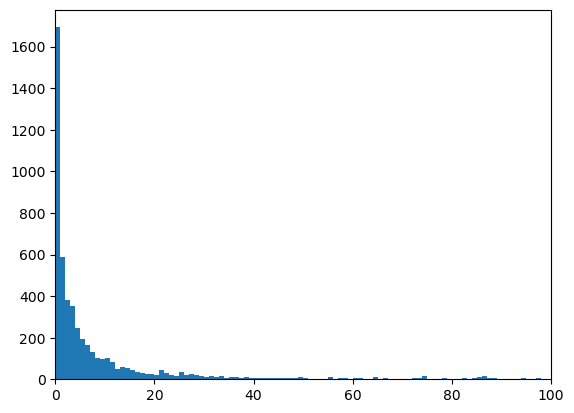

{'Q9C0F1': ['7PT5'], 'P30520': ['2V40'], 'O00468': ['8S9P'], 'Q93079': ['8OL1'], 'Q9H089': ['6LSR'], 'Q96GX9': ['4M6R'], 'P51116': ['3H8Z'], 'Q9BY44': ['8DYS'], 'O95834': ['4CGB'], 'Q9UM00': ['6W6L'], 'Q9H900': ['3IF8', '7QPG'], 'Q5T3F8': ['8EHX', '8XW4'], 'P36959': ['2BLE', '2BWG'], 'Q13217': ['2Y4T', '2Y4U'], 'Q14807': ['2EDU', '6NJE'], 'Q14697': ['8D43', '8EMR'], 'Q99856': ['2KK0', '4LJX'], 'Q8NB90': ['8RHN', '9LGO'], 'P08236': ['1BHG', '3HN3'], 'O75955': ['9BQ2', '9L3G'], 'Q15154': ['6HYL', '6HYM', '7Q46'], 'Q7Z3K3': ['2E72', '2N3A', '6EMP'], 'O95644': ['1A66', '1NFA', '5SVE'], 'Q9UIW2': ['7Y4P', '7Y4Q', '9J4C'], 'Q9HD42': ['2JQ9', '2YMB', '4A5X'], 'Q9UNZ2': ['1SS6', '8HRZ', '9MPU'], 'Q9H0F6': ['4EMO', '5X0W', '8K6P'], 'Q02218': ['3ERY', '7WGR', '8I0K'], 'Q5TDH0': ['2N7D', '4RGH', '5K57'], 'P11171': ['1GG3', '2RQ1', '3QIJ'], 'Q9Y3T9': ['8FKV', '8FKW', '8FKX', '8FKY'], 'P62995': ['2CQC', '2KXN', '2RRA', '2RRB'], 'P22090': ['5AJ0', '5FLX', '6OLG', '6OLZ'], 'Q9NZN5': ['1TXD', '1X86', 

In [1]:
from dsa.binding_interfaces.mappings.uniprot_mappings import UniprotStructureMappings
structure = UniprotStructureMappings.get_structures(["P62805"], "pdb", remove_uniprot_without_structure=True)
print(len(structure["P62805"]))
UniprotStructureMappings.plot_structure_stats(xlim=(0, 100))
uniprot_to_structure_ids = UniprotStructureMappings.representative_ids(structure_db="pdb", save=False, from_saved_file=True)
print(uniprot_to_structure_ids)

/home/shajain/DynamicSurfaceAccessibility/src/dsa/ms_dsa/Evaluation/binding_interface_eval.py:43: UserWarning: Sequence not found for uniprot_id O60361
  warnings.warn(f"Sequence not found for uniprot_id {uniprot_id}")
/home/shajain/DynamicSurfaceAccessibility/src/dsa/ms_dsa/Evaluation/binding_interface_eval.py:51: UserWarning: Lysine not correctly mapped to sequence 
  warnings.warn(f"Lysine not correctly mapped to sequence {sequence[start_index:start_index+len(peptide_seq)]}")


Inter: (55, 13)
% of Inter less than 0.9: 0.16363636363636364
Intra: (235, 13)
% of Intra less than 0.9: 0.13617021276595745
Not Contact: (597, 13)
% of Not Contact less than 0.9: 0.1273031825795645


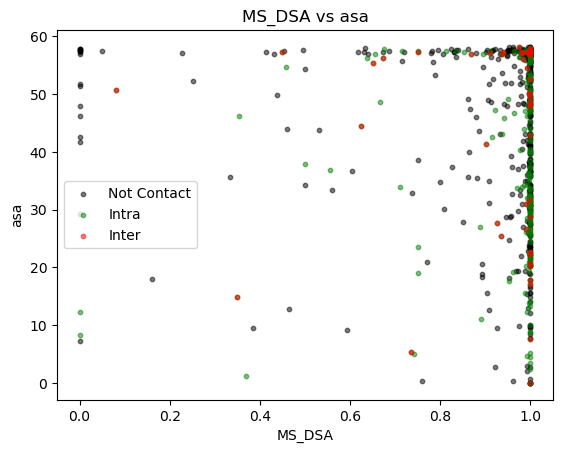

Inter: (55, 13)
% of Inter less than 0.9: 0.16363636363636364
Intra: (235, 13)
% of Intra less than 0.9: 0.13617021276595745
Not Contact: (597, 13)
% of Not Contact less than 0.9: 0.1273031825795645


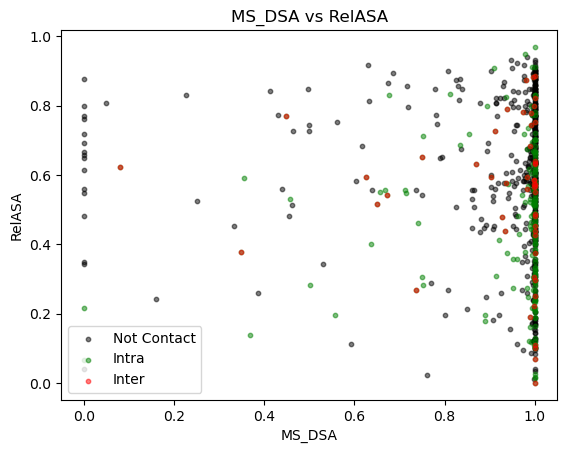

In [2]:
from dsa.ms_dsa.Evaluation.binding_interface_eval import BIEvaluation
binding_interface_eval = BIEvaluation()
#binding_interface_eval.plot_boxplot()
binding_interface_eval.plot_dsa_vs_sasa_with_binding_annotation(sasa_column="asa")
binding_interface_eval.plot_dsa_vs_sasa_with_binding_annotation(sasa_column="RelASA")

In [5]:
import pandas as pd
from dsa.config import DATA_DIR
sasa_df = pd.read_csv(DATA_DIR / "sasa" / "afold.csv")
print(sasa_df.columns)
#print(sasa_df.head())
print(sasa_df.shape)
print(sasa_df.Sequence.nunique())
print(sasa_df.Keys)


Index(['Unnamed: 0', 'seqcharge', 'Protein.Group',
       '2026-05-01_SS_CPP_argC-200ng_1hr_1',
       '2026-05-01_SS_CPP_argC-200ng_1hr_2',
       '2026-05-01_SS_CPP_argC-200ng_1hr_3',
       '2026-05-01_SS_CPP_argC-200ng_1hr_4', 'mean', 'std', 'cv', 'Sequence',
       'Keys', 'Position Start', 'Position End', 'Position K', 'asa',
       'K_count', 'ASync AA', 'pLDDT', 'RelASA', '2 Structure', 'Disorder',
       'Surface', 'dssp-key', 'NASA'],
      dtype='str')
(1118, 25)
1064
0       sp|Q8TAP8|PPR35_HUMAN
1        sp|Q13573|SNW1_HUMAN
2        sp|Q9Y5K8|VATD_HUMAN
3       sp|P04083|ANXA1_HUMAN
4       sp|P04083|ANXA1_HUMAN
                ...          
1113     sp|O75369|FLNB_HUMAN
1114     sp|P21333|FLNA_HUMAN
1115     sp|P21333|FLNA_HUMAN
1116    sp|Q12931|TRAP1_HUMAN
1117     sp|O94925|GLSK_HUMAN
Name: Keys, Length: 1118, dtype: str


In [10]:
# for seq, df in sasa_df.groupby(["Sequence", "Keys"]):
#     # print(seq)
#     # print(df.shape)
#     if df.shape[0] > 1:
#         print(df.RelASA)

df = sasa_df[["Sequence", "Keys", "RelASA"]].groupby(["Sequence", "Keys"]).agg({"RelASA": "mean"})
print(df.head())

                                                 RelASA
Sequence                Keys                           
AAAGSHFDAAKAVEEQLR      sp|Q8TAP8|PPR35_HUMAN  0.556522
AADKLAPAQYIR            sp|Q13573|SNW1_HUMAN   0.873913
AAGEVLEPANLLAEEKDEDLLFE sp|Q9Y5K8|VATD_HUMAN   0.839130
AAMKGLGTDEDTLIEILASR    sp|P04083|ANXA1_HUMAN  0.647826
AAQLQHSEKMAQYLEEER      sp|Q16204|CCDC6_HUMAN  0.465217


In [18]:
import rust_sasa_python as sasa
from dsa.binding_interfaces.config import PDB_DIR
structure_path = PDB_DIR / ("9BQ2".lower()+".cif")
#print(dir(sasa))
result = sasa.calculate_residue_sasa(structure_path.as_posix())

# print(f"Total SASA: {result.total:.2f} Å²")
print(result[0])
# per residue
# result.residues           # list of residue results
# result.per_residue        # or this

# for r in result.residues:
#     print(r.name, r.chain, r.seqid, r.sasa)

# # or as a dict
# residue_sasa = {(r.chain, r.seqid): r.sasa for r in result.residues}

Residue(chain_id='A', residue_name='MET', residue_number=1, sasa=210.540)


In [1]:
from dsa.binding_interfaces.binding_interfaces import BindingInterfaces
BI = BindingInterfaces(saved_binding_interfaces_only=True)
x = 0
found_misaligned = False
for unp, struct_dict in BI.is_aligned.items():
    for struct_id, is_aligned in struct_dict.items():
        if not is_aligned:
            print(unp, struct_id)
            x += 1
        if x > 10:
            found_misaligned = True
            break
    if found_misaligned:
        break





/home/shajain/DynamicSurfaceAccessibility/src/dsa/binding_interfaces/binding_interfaces.py:120: SyntaxWarning: invalid decimal literal
  elif isinstance(v, list) and len(v)>0and isinstance(v[0], list) and len(v[0]) ==2:


Q04917 2C74
P31153 9QPP
Q9Y5P4 6J0O
Q9Y5P4 6IF0
Q9Y5P4 5ZYJ
P01116 6W4E
P01116 6PTS
P01116 6PTW
P01116 9BI2
P01116 8QVU
P01116 7KYZ


In [ ]:
from dsa.uniprot.uniprot_to_sequence import UniprotToSequence
from dsa.binding_interfaces.process_structure.Structure import Structure
#st = Structure('2C74')
st = Structure('6QJH')
st.initialize_binding_interfaces(cutoff=cutoff)
contact_residues = st.uniprotwise_contact_residues()

print(st.structure[0][0])

from Bio.SeqUtils import seq1

def align_sequences(pdb_seq, unp_seq, pdb_alignment, offset=0):
    pdb_seq = list(pdb_seq)
    unp_seq = list(unp_seq)
    count_match = 0
    for ix_pdb, (ix_unp, res) in enumerate(zip(pdb_alignment, unp_seq)): 
        if ix_unp is not None and 0 <= ix_unp + offset < len(unp_seq):   
            match =  unp_seq[ix_unp + offset] == res
            if match:
                pdb_seq[ix_pdb] = '_'
                unp_seq[ix_unp] = '_'
                count_match += 1
    return ''.join(pdb_seq), ''.join(unp_seq), count_match
            

for unp, ents in st.uniprot_to_entity.items():
    s1 = UniprotToSequence.get_sequence(unp)
    # print(s1)
    print(unp, ents)
    for e in ents:
        for chain in st.entity_to_chains[e]:
            chainobj = [ch for ch in st.structure[0] if ch.name == chain][0]
            s2 = ''.join([seq1(r.name) for r in chainobj])
            ix = [st.sequence_aligner[chain].map(i) for i in range(1,len(s2)+1)]
            print(ix)
            print('Uniprot sequence: ', s1)
            print('PDB sequence: ', s2)
            best_match = 0
            offset_best = -1
            for offset in [-1, 0, 1, 2, -2, 3, -3]:
                pdb_seq, unp_seq, match = align_sequences(s2, s1, ix, offset=offset)
                if match > best_match:
                    best_match = match
                    offset_best = offset
            pdb_seq, unp_seq, match = align_sequences(s2, s1, ix, offset=offset_best)
            print('pdb_seq: ', pdb_seq)
            print('unp_seq: ', unp_seq)
            print('match: ', match)
            print('offset_best: ', offset_best)
            
 


         


<gemmi.Chain A with 59 res>
P10636 ['1']
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]
Uniprot sequence:  MAEPRQEFEVMEDHAGTYGLGDRKDQGGYTMHQDQEGDTDAGLKESPLQTPTEDGSEEPGSETSDAKSTPTAEDVTAPLVDEGAPGKQAAAQPHTEIPEGTTAEEAGIGDTPSLEDEAAGHVTQEPESGKVVQEGFLREPGPPGLSHQLMSGMPGAPLLPEGPREATRQPSGTGPEDTEGGRHAPELLKHQLLGDLHQEGPPLKGAGGKERPGSKEEVDEDRDVDESSPQDSPPSKASPAQDGRPPQTAAREATSIPGFPAEGAIPLPVDFLSKVSTEIPASEPDGPSVGRAKGQDAPLEFTFHVEITPNVQKEQAHSEEHLGRAAFPGAPGEGPEARGPSLGEDTKEADLPEPSEKQPAAAPRGKPVSRVPQLKARMVSKSKDGTGSDDKKAKTSTRSSAKTLKNRPCLSPKHPTPGSSDPLIQPSSPAVCPEPPSSPKYVSSVTSRTGSSGAKEMKLKGADGKTKIATPRGAAPPGQKGQANATRIPAKTPPAPKTPPSSGEPPKSGDRSGYSSPGSPGTPGSRSRTPSLPTPPTREPKKVAVVRTPPKSPSSAKSRLQTAPVPMPDLKNVKSKIGSTENLKH

In [2]:
BI.process_structure("2C74")


In [ ]:
from dsa.uniprot.sequences import Sequence

[Sequence.validate_position_residue_pairs(unp, contact_residues[unp]['all']) for unp in contact_residues]


In [1]:
from dsa.uniprot.config import ALL_UNIPROT_IDS, example_uniprot_id
from dsa.binding_interfaces.binding_interfaces import BindingInterfaces
from dsa.binding_interfaces.mappings.uniprot_mappings import UniprotStructureMappings
#uniprot_to_structure_ids = UniprotStructureMappings.get_structures(ALL_UNIPROT_IDS, "pdb", remove_ids_with_structure_ids=True)
#uniprot_id = list(uniprot_to_structure_ids.keys())[0]
uniprot_id = "P69891"
uniprot_id = "A0A672GII6"
uniprot_id = "P62805"
BI = BindingInterfaces([uniprot_id])



Processed 500 structures
Total processed 495 structures including saved ones
Total number of structure-protein pairs: 1340
Total number of unaligned structure-protein pairs: 2249


In [ ]:
BI.binding_interface(uniprot_id)

In [ ]:
print(len(uniprot_to_structure_ids.keys()))
print(len(ALL_UNIPROT_IDS))

In [ ]:
from dsa.ppi_binding_interfaces.config import test_cif_file
import gemmi
gemmi.cif.read(test_cif_file.as_posix())

In [ ]:
str(test_cif_file)

In [ ]:
from dsa.ppi_binding_interfaces.mappings.uniprot_mappings import remove_invalid_entries, get_mapped_uniprot_ids
keys = get_mapped_uniprot_ids("pdb")

In [ ]:
import numpy as np
lens = np.array([len(k.split(";")) for k in keys])

np.sum(lens==1)

In [ ]:
import dill
pair = dill.load(open("/data/dbs/dips_pdb/cc/3ccm.pdb1_2.dill", "rb"))

In [ ]:
dir(pair)

In [ ]:
id = '1tue'
s = "SGSNMSQWIRFRCSKIDEGGDWRPIVQFLRYQQIEFITFLGALKSFLKGTPKKNCLVFCGPANTGKSYFGMSFIHFIQGAVISFVNSTSHFWLEPLTDTKVAMLDDATTTCWTYFDTYMRNALDGNPISIDPLIQLKCPPILLTTNIHPAKDNRWPYLESRITVFEFPNAFPFDKNGNPVYEINDKNWKCFFERTWSRLDL"
from dsa.dips.mapping.get_sifts_data import pdb_sequence_to_uniprot
pdb_sequence_to_uniprot(id, s)


In [ ]:
from dsa.ppi_binding_interfaces.uniprot_to_pdb import get_pdb_ids_from_rcsb, download_structures_for_uniprot
print(get_pdb_ids_from_rcsb("Q5VSL9", include_computational_models=True))  # e.g. ['7K36']
download_structures_for_uniprot("Q5VSL9")

In [ ]:
row = df.iloc[0]
seq_a = row["seq_a"]
seq_b = row["seq_b"]

# Load contact map
cmap = np.load(row["contact_map"])  # shape: (L_A, L_B)

# Interface residues = any residue with at least one contact
interface_A = np.where(cmap.sum(axis=1) > 0)[0]  # indices in chain A
interface_B = np.where(cmap.sum(axis=0) > 0)[0]  # indices in chain B

# Get the actual amino acids at the interface
interface_seq_A = [seq_a[i] for i in interface_A]
interface_seq_B = [seq_b[j] for j in interface_B]

print(f"Chain A interface residues: {interface_A}")
print(f"Chain B interface residues: {interface_B}")
print(f"Interface fraction A: {len(interface_A)/len(seq_a):.2%}")
print(f"Interface fraction B: {len(interface_B)/len(seq_b):.2%}")